For Milestone 1, the task is to complete an exploratory data analysis (EDA) of the preprocessed datasets, including calculating descriptive statistics, interpreting the data, and documenting insights.

In [1]:
import pandas as pd

customer_demographics = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df1.csv')
customer_transactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df2.csv')
socmed_interactions = pd.read_csv('/content/drive/MyDrive/3rd year 2024-25/MO-IT125 - Math for Machine Learning: Linear Algebra/cleaned/df3.csv')

## **Missing Values**

In [2]:
print("\nMissing values in Customer Transactions:")
print(customer_transactions.isnull().sum())

print("\nMissing values in Social Media Interactions:")
print(socmed_interactions.isnull().sum())

print("\nMissing values in Customer Demographics:")
print(customer_demographics.isnull().sum())


Missing values in Customer Transactions:
CustomerID         0
TransactionID      0
TransactionDate    0
Amount             0
ProductCategory    0
PaymentMethod      0
dtype: int64

Missing values in Social Media Interactions:
CustomerID         0
InteractionID      0
InteractionDate    0
Platform           0
InteractionType    0
Sentiment          0
dtype: int64

Missing values in Customer Demographics:
CustomerID     0
Age            0
Gender         0
Location       0
IncomeLevel    0
SignupDate     0
dtype: int64


## **Descriptive Statistics Overview**

The following section generates and displays key descriptive statistics for each dataset. This includes metrics such as:

- **Count**: The number of non-null entries.
- **Mean**: The average value of the dataset.
- **Standard Deviation**: A measure of the spread or dispersion in the data.
- **Minimum and Maximum**: The smallest and largest values in the dataset.
- **Percentiles (25%, 50%, 75%)**: Quartile values, which provide insights into the distribution of the data.

These statistics offer a snapshot of the central tendencies and variability within each dataset, helping to understand its basic structure and characteristics.


In [3]:
# Customer Demographics
print("Customer Demographics Summary Statistics:")
print(customer_demographics.describe())

# Customer Transactions
print("\nCustomer Transactions Summary Statistics:")
print(customer_transactions.describe())

# Social Media Interactions
print("\nSocial Media Interactions Summary Statistics:")
print(socmed_interactions.describe().to_string())

Customer Demographics Summary Statistics:
               Age
count  2650.000000
mean     44.644906
std      15.405637
min      18.000000
25%      31.000000
50%      45.000000
75%      58.000000
max      70.000000

Customer Transactions Summary Statistics:
            Amount
count  3015.000000
mean    489.789032
std     283.275830
min    -100.000000
25%     254.540000
50%     489.790000
75%     720.395000
max     999.860000

Social Media Interactions Summary Statistics:
                                  CustomerID                         InteractionID InteractionDate   Platform InteractionType Sentiment
count                                   3020                                  3020            3020       3020            3020      3020
unique                                  1893                                  3000             366          4               3         6
top     fd35b6b4-ad1c-49cc-9c34-8c2d696f38e2  98cf7859-e4a9-465b-96fe-ed51a1f1aa92      2023-07-02  Instagram         

## **Data Structure Overview and Memory Usage**

In this section, we inspect the structure and composition of each dataset—Customer Transactions, Social Media Interactions, and Customer Demographics—by using the `.info()` method. This method provides a summary of the following:

* Column Names: Displays the names of all columns in the dataset.
* Non-null Counts: Shows how many non-null (non-missing) values each column contains, indicating the completeness of the data.
* Data Types: Identifies the type of data stored in each column (e.g., float64 for numerical values, category for categorical values, object for string-like data).
* Memory Usage: Provides an estimate of the memory footprint of each dataset, which is useful for optimizing performance, especially with large datasets.

By reviewing this output, we gain a comprehensive understanding of the datasets' structures, which helps in the subsequent analysis and processing stages.

In [4]:
print("\nDetailed Info for Customer Transactions:")
customer_transactions.info()

print("\nDetailed Info for Social Media Interactions:")
socmed_interactions.info()

print("\nDetailed Info for Customer Demographics:")
customer_demographics.info()


Detailed Info for Customer Transactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       3015 non-null   object 
 1   TransactionID    3015 non-null   object 
 2   TransactionDate  3015 non-null   object 
 3   Amount           3015 non-null   float64
 4   ProductCategory  3015 non-null   object 
 5   PaymentMethod    3015 non-null   object 
dtypes: float64(1), object(5)
memory usage: 141.5+ KB

Detailed Info for Social Media Interactions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020 entries, 0 to 3019
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       3020 non-null   object
 1   InteractionID    3020 non-null   object
 2   InteractionDate  3020 non-null   object
 3   Platform         3020 non-null   object
 4   Int

## **Data Type Conversion for Key Datasets**

In this section, we standardize the data types for columns in the **Customer Demographics**, **Customer Transactions**, and **Social Media Interactions** datasets. Converting the data types ensures consistency and prepares the data for accurate analysis and efficient storage.

- **Customer Demographics**:
   - Converts `CustomerID` and `Location` to `string` for consistency.
   - Converts `Age` to `float64` for numerical analysis.
   - Converts `Gender` and `IncomeLevel` to `category`, which optimizes memory and improves performance for categorical data.
   - Converts `SignupDate` to `date` to work with date-related operations.

- **Customer Transactions**:
   - Converts `CustomerID` and `TransactionID` to `string`.
   - Converts `TransactionDate` to `date` for date-related operations.
   - Rounds `Amount` to two decimal places for financial accuracy.
   - Converts `PaymentMethod` to `category` for optimized handling of categorical data.

- **Social Media Interactions**:
   - Converts `CustomerID` and `InteractionID` to `string`.
   - Converts `InteractionDate` to `date` for time-related analysis.
   - Converts `Platform`, `InteractionType`, and `Sentiment` to `category` for optimized memory usage and faster operations on categorical values.

After applying these conversions, the `info()` method is used to verify the changes in data types and check the non-null counts, ensuring the data is clean and ready for further analysis.


In [5]:

# For Customer Demographics
customer_demographics['CustomerID'] = customer_demographics['CustomerID'].astype('string')
customer_demographics['Age'] = customer_demographics['Age'].astype('float64')
customer_demographics['Gender'] = customer_demographics['Gender'].astype('category')
customer_demographics['Location'] = customer_demographics['Location'].astype('string')
customer_demographics['IncomeLevel'] = customer_demographics['IncomeLevel'].astype('category')
customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate']).dt.date

# For Customer Transactions
customer_transactions['CustomerID'] = customer_transactions['CustomerID'].astype('string')
customer_transactions['TransactionID'] = customer_transactions['TransactionID'].astype('string')
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate']).dt.date
customer_transactions['Amount'] = customer_transactions['Amount'].round(2)  # Rounding to 2 decimal places
customer_transactions['PaymentMethod'] = customer_transactions['PaymentMethod'].astype('category')

# For Social Media Interactions
socmed_interactions['CustomerID'] = socmed_interactions['CustomerID'].astype('string')
socmed_interactions['InteractionID'] = socmed_interactions['InteractionID'].astype('string')
socmed_interactions['InteractionDate'] = pd.to_datetime(socmed_interactions['InteractionDate']).dt.date
socmed_interactions['Platform'] = socmed_interactions['Platform'].astype('category')
socmed_interactions['InteractionType'] = socmed_interactions['InteractionType'].astype('category')
socmed_interactions['Sentiment'] = socmed_interactions['Sentiment'].astype('category')

# Verifying the changes
print("\nNew Customer Demographics Info:")
print(customer_demographics.info())

print("\nNew Customer Transactions Info:")
print(customer_transactions.info())

print("\nNew Social Media Interactions Info:")
print(socmed_interactions.info())



New Customer Demographics Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2650 entries, 0 to 2649
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   CustomerID   2650 non-null   string  
 1   Age          2650 non-null   float64 
 2   Gender       2650 non-null   category
 3   Location     2650 non-null   string  
 4   IncomeLevel  2650 non-null   category
 5   SignupDate   2650 non-null   object  
dtypes: category(2), float64(1), object(1), string(2)
memory usage: 88.4+ KB
None

New Customer Transactions Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015 entries, 0 to 3014
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CustomerID       3015 non-null   string  
 1   TransactionID    3015 non-null   string  
 2   TransactionDate  3015 non-null   object  
 3   Amount           3015 non-null   float64 
 4   ProductCa

## **Frequency Counts for Categorical Variables**

In this section, we calculate and display the frequency counts for categorical variables in the **Customer Demographics**, **Customer Transactions**, and **Social Media Interactions** datasets. This allows us to better understand the distribution of categories within each dataset, providing insights into the most common categories and their respective occurrences.

- **Customer Demographics**:
   - **Gender Distribution**: Counts the occurrences of each gender category (e.g., Male, Female).
   - **Income Level Distribution**: Displays the distribution of customers across different income levels (e.g., Low, Medium, High).

- **Customer Transactions**:
   - **Product Category Distribution**: Shows the count of transactions for each product category (e.g., Clothing, Health & Beauty, Automotive).
   - **Payment Method Distribution**: Lists the frequency of each payment method used (e.g., PayPal, Bank Transfer, Debit Card).

- **Social Media Interactions**:
   - **Platform Distribution**: Displays the frequency of interactions across different social media platforms (e.g., Twitter, Instagram).
   - **Interaction Type Distribution**: Provides the count of each type of interaction (e.g., Likes, Comments, Shares).
   - **Sentiment Distribution**: Shows the sentiment breakdown (e.g., Neutral, Positive, Negative, Uncategorized) for social media interactions.

These frequency counts give an overview of how the categorical data is distributed, helping to identify trends and common patterns within the datasets.


In [6]:
# Frequency Counts for Categorical Variables

# For Customer Demographics
print("Customer Demographics - Gender Distribution:")
print(customer_demographics['Gender'].value_counts())

print("\nCustomer Demographics - Income Level Distribution:")
print(customer_demographics['IncomeLevel'].value_counts())

# For Customer Transactions
print("\nCustomer Transactions - Product Category Distribution:")
print(customer_transactions['ProductCategory'].value_counts())

print("\nCustomer Transactions - Payment Method Distribution:")
print(customer_transactions['PaymentMethod'].value_counts())

# For Social Media Interactions
print("\nSocial Media Interactions - Platform Distribution:")
print(socmed_interactions['Platform'].value_counts())

print("\nSocial Media Interactions - Interaction Type Distribution:")
print(socmed_interactions['InteractionType'].value_counts())

print("\nSocial Media Interactions - Sentiment Distribution:")
print(socmed_interactions['Sentiment'].value_counts())


Customer Demographics - Gender Distribution:
Gender
Female    1334
Male      1316
Name: count, dtype: int64

Customer Demographics - Income Level Distribution:
IncomeLevel
High             825
Low              816
Medium           770
Uncategorized    239
Name: count, dtype: int64

Customer Transactions - Product Category Distribution:
ProductCategory
Clothing           571
Electronics        564
Automotive         540
Home & Garden      530
Health & Beauty    528
Uncategorized      282
Name: count, dtype: int64

Customer Transactions - Payment Method Distribution:
PaymentMethod
Debit Card       767
Credit Card      755
PayPal           750
Bank Transfer    743
Name: count, dtype: int64

Social Media Interactions - Platform Distribution:
Platform
Instagram        921
Twitter          917
Facebook         891
Uncategorized    291
Name: count, dtype: int64

Social Media Interactions - Interaction Type Distribution:
InteractionType
Comment    1018
Share      1007
Like        995
Name: cou

Customer Demographics - Gender Distribution:
Gender
Female    1334
Male      1316
Name: count, dtype: int64

Customer Demographics - Income Level Distribution:
IncomeLevel
High             825
Low              816
Medium           770
Uncategorized    239
Name: count, dtype: int64


<ipython-input-14-a86566967ed2>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=column, palette=palette)


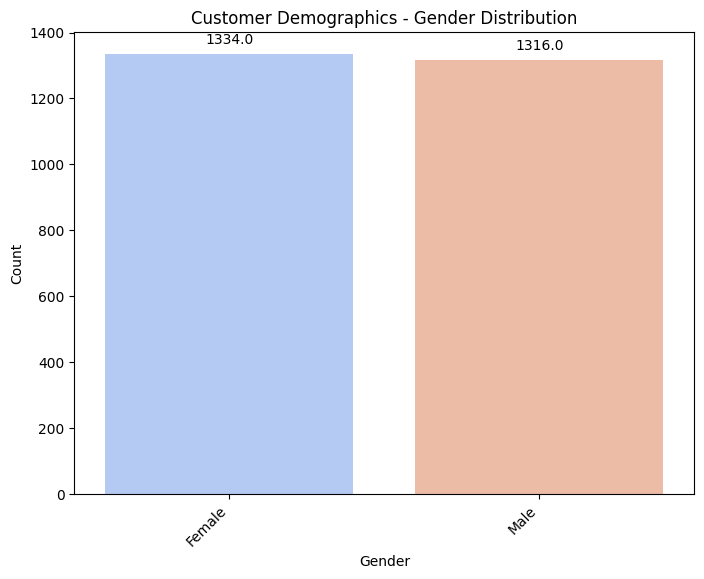

<ipython-input-14-a86566967ed2>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=column, palette=palette)


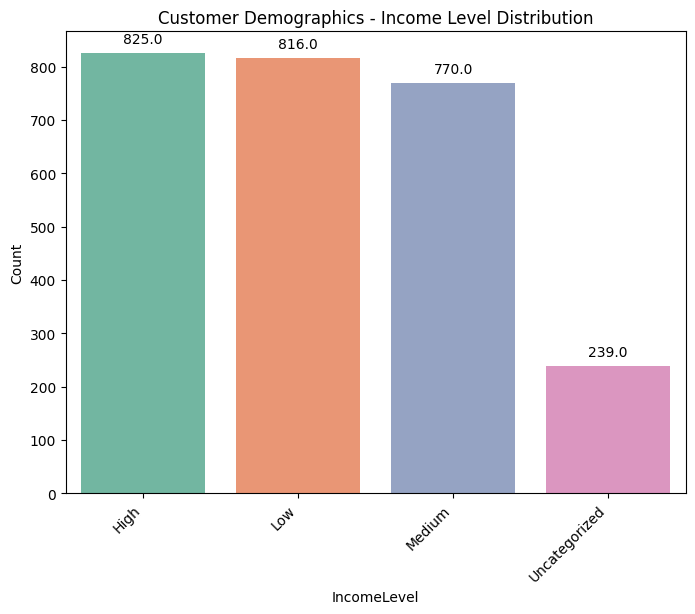

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print value counts (optional)
print("Customer Demographics - Gender Distribution:")
print(customer_demographics['Gender'].value_counts())

print("\nCustomer Demographics - Income Level Distribution:")
print(customer_demographics['IncomeLevel'].value_counts())

# Create plots with values on top of bars and customized colors
def plot_distribution_with_values(data, column, title, palette):
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=data, x=column, palette=palette)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Add the values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.show()

# Define custom color palettes
gender_palette = sns.color_palette("coolwarm", len(customer_demographics['Gender'].unique()))
income_palette = sns.color_palette("Set2", len(customer_demographics['IncomeLevel'].unique()))

# Plot Gender distribution with custom color palette
plot_distribution_with_values(customer_demographics, 'Gender', 'Customer Demographics - Gender Distribution', gender_palette)

# Plot IncomeLevel distribution with custom color palette
plot_distribution_with_values(customer_demographics, 'IncomeLevel', 'Customer Demographics - Income Level Distribution', income_palette)



Customer Transactions - Product Category Distribution:
ProductCategory
Clothing           571
Electronics        564
Automotive         540
Home & Garden      530
Health & Beauty    528
Uncategorized      282
Name: count, dtype: int64

Customer Transactions - Payment Method Distribution:
PaymentMethod
Debit Card       767
Credit Card      755
PayPal           750
Bank Transfer    743
Name: count, dtype: int64


<ipython-input-15-59a49b24574f>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=column, palette=palette)


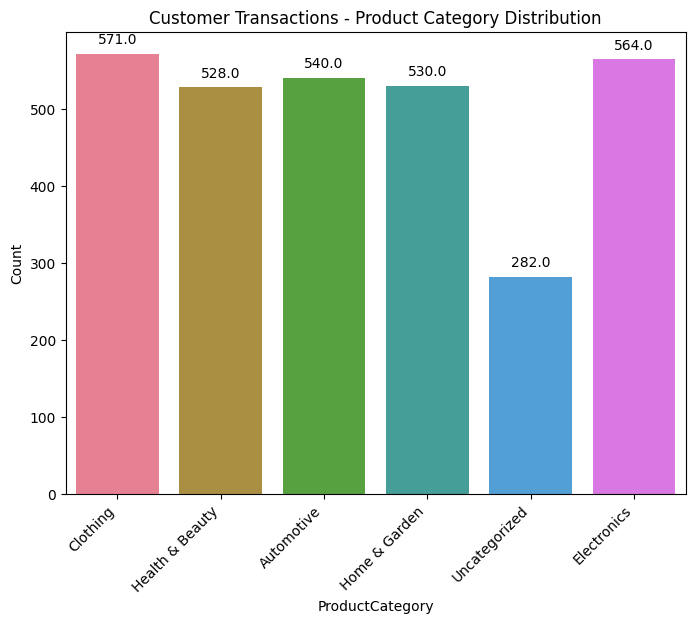

<ipython-input-15-59a49b24574f>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=column, palette=palette)


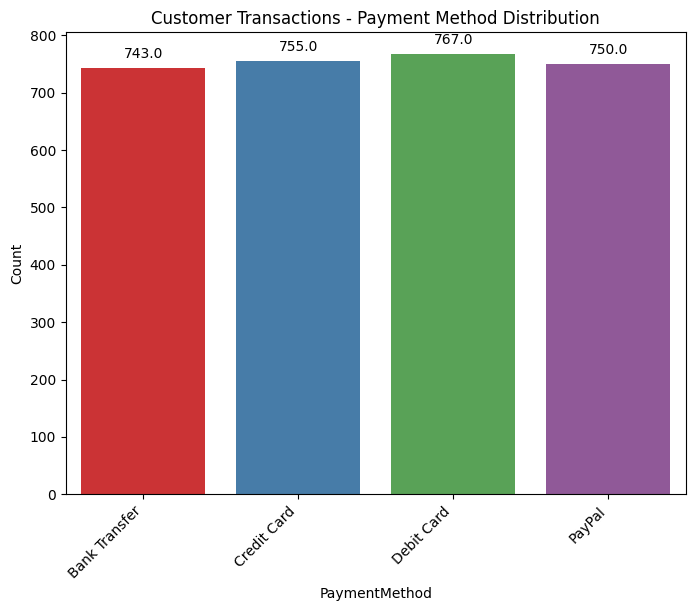

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the DataFrame 'customer_transactions' is already loaded

# Print value counts (optional)
print("\nCustomer Transactions - Product Category Distribution:")
print(customer_transactions['ProductCategory'].value_counts())

print("\nCustomer Transactions - Payment Method Distribution:")
print(customer_transactions['PaymentMethod'].value_counts())

# Function to create plots with values on top of bars and custom colors
def plot_distribution_with_values(data, column, title, palette):
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(data=data, x=column, palette=palette)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')

    # Add the values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), textcoords='offset points')

    plt.show()

# Define custom color palettes
product_category_palette = sns.color_palette("husl", len(customer_transactions['ProductCategory'].unique()))
payment_method_palette = sns.color_palette("Set1", len(customer_transactions['PaymentMethod'].unique()))

# Plot Product Category distribution with custom color palette
plot_distribution_with_values(customer_transactions, 'ProductCategory', 'Customer Transactions - Product Category Distribution', product_category_palette)

# Plot Payment Method distribution with custom color palette
plot_distribution_with_values(customer_transactions, 'PaymentMethod', 'Customer Transactions - Payment Method Distribution', payment_method_palette)



Social Media Interactions - Platform Distribution:
Platform
Instagram        921
Twitter          917
Facebook         891
Uncategorized    291
Name: count, dtype: int64

Social Media Interactions - Interaction Type Distribution:
InteractionType
Comment    1018
Share      1007
Like        995
Name: count, dtype: int64

Social Media Interactions - Sentiment Distribution:
Sentiment
Positive         905
Neutral          874
Negative         866
Uncategorized    309
Very Negative     34
Very Positive     32
Name: count, dtype: int64


<ipython-input-13-445c66ff5b1e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


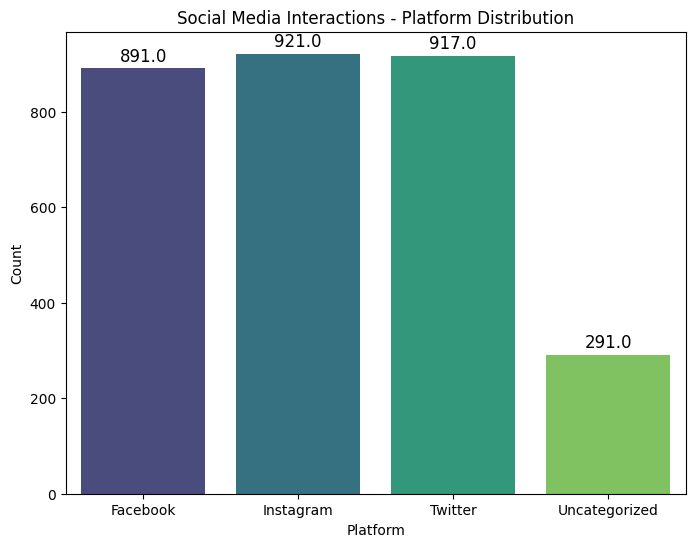

<ipython-input-13-445c66ff5b1e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


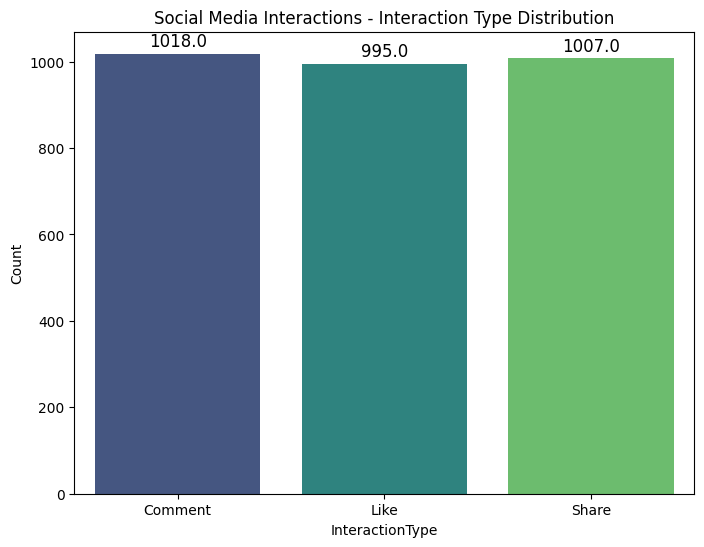

<ipython-input-13-445c66ff5b1e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


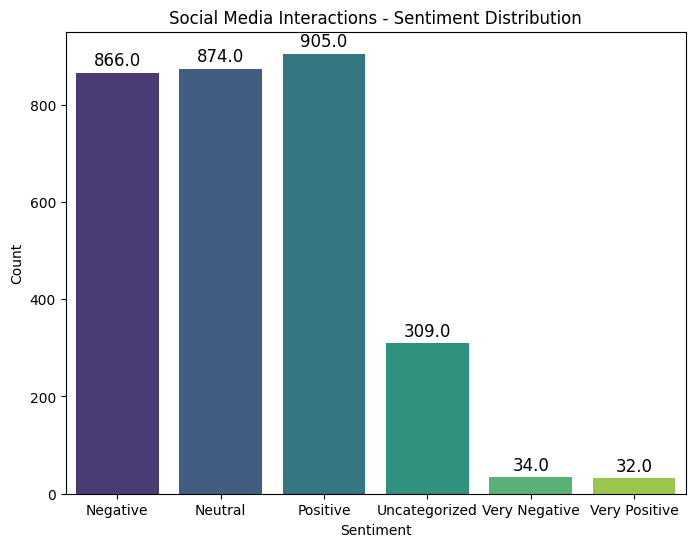

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot distribution with values on top of bars
def plot_distribution_with_values(df, column, title):
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=column, data=df, palette='viridis')
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Add the values on top of the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

    plt.show()

# For Social Media Interactions
print("\nSocial Media Interactions - Platform Distribution:")
print(socmed_interactions['Platform'].value_counts())

print("\nSocial Media Interactions - Interaction Type Distribution:")
print(socmed_interactions['InteractionType'].value_counts())

print("\nSocial Media Interactions - Sentiment Distribution:")
print(socmed_interactions['Sentiment'].value_counts())

# Create plots with values on top of bars
plot_distribution_with_values(socmed_interactions, 'Platform', 'Social Media Interactions - Platform Distribution')
plot_distribution_with_values(socmed_interactions, 'InteractionType', 'Social Media Interactions - Interaction Type Distribution')
plot_distribution_with_values(socmed_interactions, 'Sentiment', 'Social Media Interactions - Sentiment Distribution')


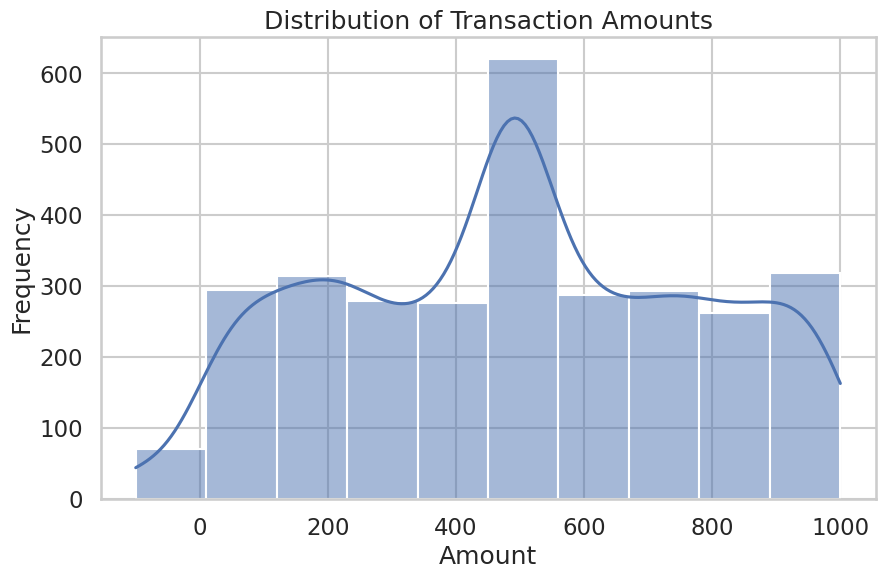

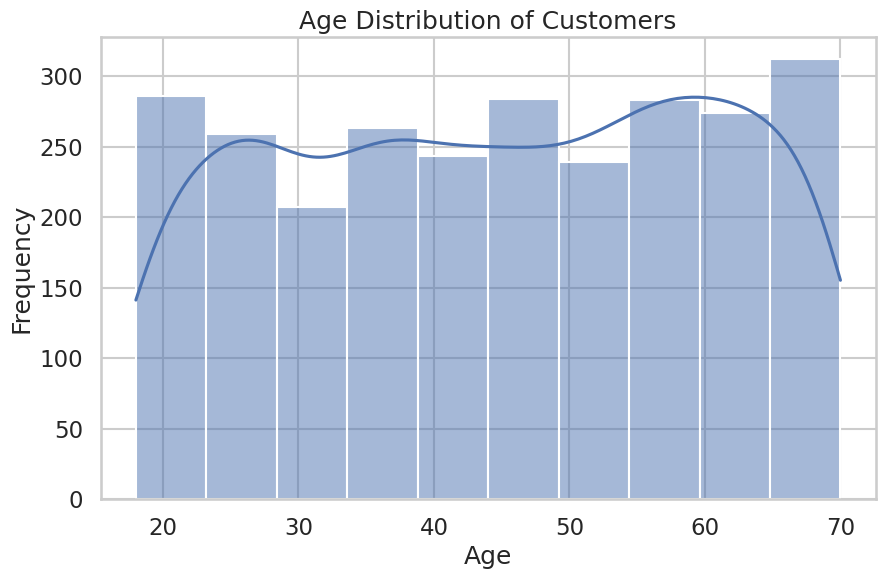

In [18]:
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Transactions - Distribution of Amount Spent
plt.figure(figsize=(10,6))
sns.histplot(customer_transactions['Amount'], bins=10, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Demographics - Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(customer_demographics['Age'], bins=10, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## **Identifying Outliers**

In [10]:
def find_outliers_iqr(df, df_name):
    outliers_dict = {}

    for col in df.select_dtypes(include=['number']):  # Iterate over numerical columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        # If outliers are found, store them in the dictionary
        if not outliers.empty:
            outliers_dict[col] = outliers
            print(f"\nOutliers detected in {col} in {df_name}:")
            print(f"Number of outliers: {len(outliers)}")
        else:
            print(f"\nNo outliers detected in {col} in {df_name}.")

    return outliers_dict

# Find outliers using IQR for each DataFrame
customer_transactions_outliers = find_outliers_iqr(customer_transactions, "Customer Transactions")
customer_demographics_outliers = find_outliers_iqr(customer_demographics, "Customer Demographics")
socmed_interactions_outliers = find_outliers_iqr(socmed_interactions, "Social Media Interactions")



No outliers detected in Amount in Customer Transactions.

No outliers detected in Amount_zscore in Customer Transactions.

No outliers detected in Age in Customer Demographics.

No outliers detected in Age_zscore in Customer Demographics.



Outliers in Amount in Customer Transactions based on z-score:
Empty DataFrame
Columns: [CustomerID, TransactionID, TransactionDate, Amount, ProductCategory, PaymentMethod, Amount_zscore]
Index: []


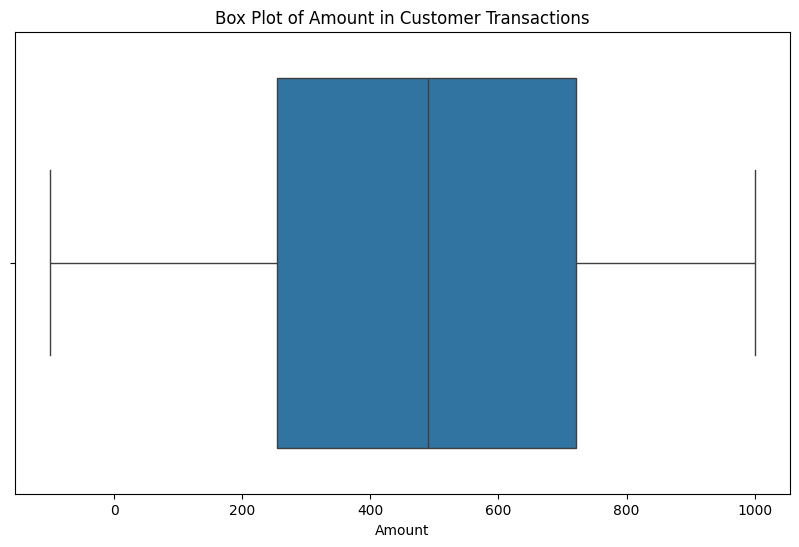


Outliers in Age in Customer Demographics based on z-score:
Empty DataFrame
Columns: [CustomerID, Age, Gender, Location, IncomeLevel, SignupDate, Age_zscore]
Index: []


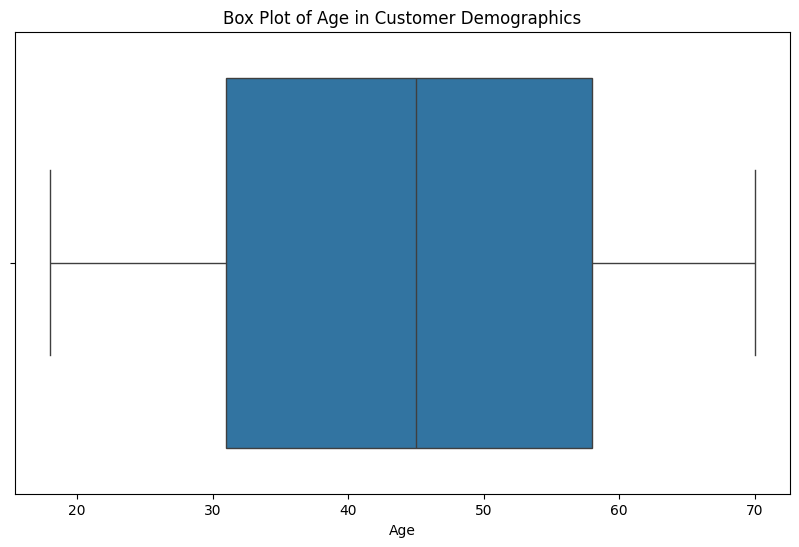

In [9]:
!pip install scipy

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Function to find and visualize outliers for numerical columns in a DataFrame
def find_and_visualize_outliers(df, df_name):
  for col in df.select_dtypes(include=['number']):
    df[col + '_zscore'] = stats.zscore(df[col])
    outliers = df[(df[col + '_zscore'] > 3) | (df[col + '_zscore'] < -3)]
    print(f"\nOutliers in {col} in {df_name} based on z-score:")
    print(outliers)

    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col} in {df_name}')
    plt.xlabel(col)
    plt.show()

# Find and visualize outliers for each DataFrame
find_and_visualize_outliers(customer_transactions, "Customer Transactions")
find_and_visualize_outliers(customer_demographics, "Customer Demographics")
find_and_visualize_outliers(socmed_interactions, "Social Media Interactions")

## **Analysis for Customer Demographics**

In [47]:
# For customer_demographics

# 1. Overview of Age Distribution
print("\n=== Age Distribution ===")
age_summary = customer_demographics['Age'].describe()
print(f"Age Summary Statistics:\n{age_summary}\n")

# 2. Gender Distribution
print("\n=== Gender Distribution ===")
gender_counts = customer_demographics['Gender'].value_counts()
print(f"Number of Customers by Gender:\n{gender_counts}\n")

# 3. Income Level Distribution
print("\n=== Income Level Distribution ===")
income_level_counts = customer_demographics['IncomeLevel'].value_counts()
print(f"Number of Customers by Income Level:\n{income_level_counts}\n")

# 4. Age Distribution by Gender
print("\n=== Age Distribution by Gender ===")
# Pass observed=True to remove the warning
age_by_gender = customer_demographics.groupby('Gender', observed=True)['Age'].mean().reset_index()
print(f"Average Age by Gender:\n{age_by_gender}\n")

# 5. Age Distribution by Income Level
print("\n=== Age Distribution by Income Level ===")
# Pass observed=True to remove the warning
age_by_income_level = customer_demographics.groupby('IncomeLevel', observed=True)['Age'].mean().reset_index()
print(f"Average Age by Income Level:\n{age_by_income_level}\n")

# 6. Number of Customers by Location
print("\n=== Number of Customers by Location ===")
location_counts = customer_demographics['Location'].value_counts().head(10)  # Display top 10 locations by customer count
print(f"Number of Customers by Location (Top 10 Locations):\n{location_counts}\n")

# 7. Signup Date Overview
print("\n=== Signup Date Overview ===")
customer_demographics['SignupDate'] = pd.to_datetime(customer_demographics['SignupDate'])
signup_counts_by_year = customer_demographics['SignupDate'].dt.year.value_counts().sort_index()
print(f"Number of Signups by Year:\n{signup_counts_by_year}\n")

# 8. Age Distribution Over Time
print("\n=== Age Distribution Over Time ===")
age_over_time = customer_demographics.groupby(customer_demographics['SignupDate'].dt.year)['Age'].mean().reset_index()
print(f"Average Age of Customers by Signup Year:\n{age_over_time}\n")



=== Age Distribution ===
Age Summary Statistics:
count    2650.000000
mean       44.644906
std        15.405637
min        18.000000
25%        31.000000
50%        45.000000
75%        58.000000
max        70.000000
Name: Age, dtype: float64


=== Gender Distribution ===
Number of Customers by Gender:
Gender
Female    1334
Male      1316
Name: count, dtype: int64


=== Income Level Distribution ===
Number of Customers by Income Level:
IncomeLevel
High             825
Low              816
Medium           770
Uncategorized    239
Name: count, dtype: int64


=== Age Distribution by Gender ===
Average Age by Gender:
   Gender        Age
0  Female  45.176912
1    Male  44.105623


=== Age Distribution by Income Level ===
Average Age by Income Level:
     IncomeLevel        Age
0           High  45.069091
1            Low  44.224265
2         Medium  45.015584
3  Uncategorized  43.422594


=== Number of Customers by Location ===
Number of Customers by Location (Top 10 Locations):
Location

### Interpretation of Customer Demographics Analysis:

- **Age Distribution**:
  - The average age of customers is approximately 44.6 years.
  - The youngest customer is 18 years old, while the oldest is 70.
  - The middle 50% of customers are aged between 31 and 58 years.

- **Gender Distribution**:
  - The dataset has a fairly balanced gender split:
    - 1,334 (50.34%) are female.
    - 1,316 (49.66%) are male.

- **Income Level Distribution**:
  - The majority of customers fall into these income levels:
    - 825 (31.1%) customers are classified as High income.
    - 816 (30.8%) customers are classified as Low income.
    - 770 (29.1%) customers are in the Medium income level.
    - 239 (9%) customers are Uncategorized.

- **Age Distribution by Gender**:
  - The average age of female customers is 45.18 years.
  - The average age of male customers is slightly lower at 44.11 years.

- **Age Distribution by Income Level**:
  - High-income customers have an average age of 45.07 years.
  - Low-income customers have an average age of 44.22 years.
  - Medium-income customers have an average age of 45.02 years.
  - Uncategorized customers are younger on average, with an average age of 43.42 years.

- **Number of Customers by Location**:
  - No single location has a dominant number of customers.
  - The top 10 locations, including "Port Michael" and "West Robert," have only a few customers each, ranging from 3 to 5.

- **Signup Date Overview**:
  - Customer signups have been consistent across the years:
    - 2019 had 261 signups.
    - 2020 had the highest number with 541 signups.
    - 2024 had fewer signups, likely because the year is still ongoing, with 286 so far.

- **Age Distribution Over Time**:
  - The average age of customers signing up has been fairly stable over the years, ranging between 43.65 and 45.70 years.
  - The highest average age of signups occurred in 2021 (45.70 years).

This analysis highlights the overall demographics of your customer base, providing insights into age, gender, income level, and location patterns. The data indicates a relatively balanced gender distribution, a stable customer age range, and consistent growth in signups over the years.

## **Analysis for Customer Transactions**

In [41]:
# For customer_transactions

# 1. Overview of Transaction Dates
print("\n=== Transaction Dates Overview ===")
unique_transaction_dates = customer_transactions['TransactionDate'].nunique()
print(f"Unique Transaction Dates: {unique_transaction_dates}\n")

# Find which TransactionDate has the highest total amount and highest single amount
total_amount_by_date = customer_transactions.groupby('TransactionDate')['Amount'].sum().reset_index()
highest_amount_date = total_amount_by_date.sort_values(by='Amount', ascending=False).head(1)
print(f"Date with the Highest Total Amount:\n{highest_amount_date}\n")

# Highest single amount by TransactionDate
highest_single_transaction = customer_transactions[['TransactionDate', 'Amount']].sort_values(by='Amount', ascending=False).head(1)
print(f"Date with the Highest Single Transaction Amount:\n{highest_single_transaction}\n")

# 2. Product Category Analysis
print("\n=== Product Category Analysis ===")
# Total amount by ProductCategory
total_amount_by_category = customer_transactions.groupby('ProductCategory')['Amount'].sum().reset_index()
highest_amount_category = total_amount_by_category.sort_values(by='Amount', ascending=False).head(1)
print(f"Product Category with the Highest Total Amount:\n{highest_amount_category}\n")

# Highest single amount by ProductCategory
highest_single_product_category = customer_transactions[['ProductCategory', 'Amount']].sort_values(by='Amount', ascending=False).head(1)
print(f"Product Category with the Highest Single Transaction Amount:\n{highest_single_product_category}\n")

# 3. Payment Method Analysis
print("\n=== Payment Method Analysis ===")
# Total amount by PaymentMethod
total_amount_by_payment_method = customer_transactions.groupby('PaymentMethod', observed=True)['Amount'].sum().reset_index()
highest_amount_payment_method = total_amount_by_payment_method.sort_values(by='Amount', ascending=False).head(1)
print(f"Payment Method with the Highest Total Amount:\n{highest_amount_payment_method}\n")

# Highest single amount by PaymentMethod
highest_single_payment_method = customer_transactions[['PaymentMethod', 'Amount']].sort_values(by='Amount', ascending=False).head(1)
print(f"Payment Method with the Highest Single Transaction Amount:\n{highest_single_payment_method}\n")

# 4. Customer Spending Behavior
print("\n=== Customer Spending Behavior ===")
# Total and average amount spent by each customer
customer_spending = customer_transactions.groupby('CustomerID')['Amount'].agg(['sum', 'mean', 'count']).reset_index()
customer_spending.columns = ['CustomerID', 'TotalSpent', 'AvgSpent', 'TransactionCount']
print(f"Customer Spending Behavior (Top 10 by Total Spent):\n{customer_spending.sort_values(by='TotalSpent', ascending=False).head(10)}\n")

# 5. Product Categories by Payment Method
print("\n=== Top Product Categories by Payment Method ===")
top_products_by_payment_method = customer_transactions.groupby(['PaymentMethod', 'ProductCategory'], observed=True)['Amount'].sum().reset_index()
print(f"Top Product Categories by Payment Method:\n{top_products_by_payment_method.sort_values(by='Amount', ascending=False)}\n")

# 6. Repeat Customers Analysis
print("\n=== Repeat Customers ===")
# Count number of transactions per customer
customer_transaction_counts = customer_transactions.groupby('CustomerID').size().reset_index(name='TransactionCount')

# Identify repeat customers (customers with more than one transaction)
repeat_customers = customer_transaction_counts[customer_transaction_counts['TransactionCount'] > 1]
print(f"Repeat Customers (more than one transaction):\n{repeat_customers}\n")

# 7. Free or Discounted Transactions
print("\n=== Free or Discounted Transactions ===")
# Count the number of free or discounted transactions (where 'Amount' is 0)
free_transactions_count = customer_transactions[customer_transactions['Amount'] == 0].shape[0]
print(f"Number of Free or Discounted Transactions: {free_transactions_count}\n")


# 8. Product Category Trends Over Time
print("\n=== Product Category Trends Over Time ===")
# Convert 'TransactionDate' to datetime if it's not already
customer_transactions['TransactionDate'] = pd.to_datetime(customer_transactions['TransactionDate'])

# Group by ProductCategory and month to see how categories perform over time
product_trends = customer_transactions.groupby([customer_transactions['TransactionDate'].dt.to_period('M'), 'ProductCategory'])['Amount'].sum().reset_index()
print(f"Product Category Popularity Over Time:\n{product_trends}\n")



=== Transaction Dates Overview ===
Unique Transaction Dates: 716

Date with the Highest Total Amount:
    TransactionDate  Amount
163      2022-12-14  6128.2

Date with the Highest Single Transaction Amount:
    TransactionDate  Amount
745      2023-01-15  999.86


=== Product Category Analysis ===
Product Category with the Highest Total Amount:
  ProductCategory     Amount
1        Clothing  281002.53

Product Category with the Highest Single Transaction Amount:
    ProductCategory  Amount
745     Electronics  999.86


=== Payment Method Analysis ===
Payment Method with the Highest Total Amount:
  PaymentMethod     Amount
2    Debit Card  377368.23

Payment Method with the Highest Single Transaction Amount:
    PaymentMethod  Amount
745   Credit Card  999.86


=== Customer Spending Behavior ===
Customer Spending Behavior (Top 10 by Total Spent):
                                CustomerID  TotalSpent    AvgSpent  \
522   49f06ea9-4ae5-4ce5-98ce-d2c2f6f15cbd     4023.73  670.621667   


### Interpretation of Customer Transactions Analysis:

- **Transaction Dates Overview**:
  - There are **716 unique transaction dates**.
  - The **highest total transaction amount** on a single day occurred on **2022-12-14**, with transactions totaling **6,128.2**.
  - The **highest single transaction** occurred on **2023-01-15** with an amount of **999.86**.

- **Product Category Analysis**:
  - **Clothing** had the highest total transaction amount with **281,002.53**.
  - The **highest single transaction** within a product category was in **Electronics** with **999.86**.

- **Payment Method Analysis**:
  - **Debit Card** was the payment method with the highest total transaction amount of **377,368.23**.
  - The **highest single transaction** using a **Credit Card** was **999.86**.

- **Customer Spending Behavior**:
  - The customer with the **highest total spending** spent **4,023.73** across **6 transactions**.
  - The **average spending per transaction** among the top customers varies from **502.92** to **883.02**.

- **Top Product Categories by Payment Method**:
  - **Debit Card** had the highest total amount spent on **Electronics** (**82,551.78**).
  - **PayPal** had the highest amount spent on **Automotive** (**76,937.31**).
  - **Bank Transfer** had the highest amount spent on **Home & Garden** (**74,653.69**).

- **Repeat Customers**:
  - There are **815 customers** who made more than one transaction.
  - Some customers made up to **4 or more transactions**.

- **Free or Discounted Transactions**:
  - There were **30 transactions** where the amount was free or discounted to **0**.

- **Product Category Trends Over Time**:
  - **Clothing** was the most popular product category over time with consistent high amounts across different months.
  - **Home & Garden** and **Automotive** also showed strong sales during different periods.
  - **Uncategorized** products were less frequent but still had notable transactions, peaking at **2872.04** in June 2024.

This analysis highlights key transaction patterns, spending behavior, and customer engagement, providing useful insights into the performance of different product categories and payment methods over time.

## **Analysis for Social Media Interaction**

In [45]:
# For Social Media Interactions

# 1. Overview of Interaction Dates
print("\n=== Interaction Dates Overview ===")
unique_interaction_dates = socmed_interactions['InteractionDate'].nunique()
print(f"Unique Interaction Dates: {unique_interaction_dates}\n")

# 2. Platform Analysis
print("\n=== Platform Analysis ===")
platform_counts = socmed_interactions['Platform'].value_counts()
print(f"Number of Interactions by Platform:\n{platform_counts}\n")

# 3. Interaction Type Analysis
print("\n=== Interaction Type Analysis ===")
interaction_type_counts = socmed_interactions['InteractionType'].value_counts()
print(f"Number of Interactions by Type:\n{interaction_type_counts}\n")

# 4. Sentiment Analysis
print("\n=== Sentiment Analysis ===")
sentiment_counts = socmed_interactions['Sentiment'].value_counts()
print(f"Number of Interactions by Sentiment:\n{sentiment_counts}\n")

# 5. Platform vs. Interaction Type Analysis
print("\n=== Platform vs. Interaction Type Analysis ===")
# Pass observed=True to remove the warning
platform_interaction_type = socmed_interactions.groupby(['Platform', 'InteractionType'], observed=True).size().reset_index(name='Count')
print(f"Number of Interactions by Platform and Type:\n{platform_interaction_type.sort_values(by='Count', ascending=False)}\n")

# 6. Sentiment Distribution by Platform
print("\n=== Sentiment Distribution by Platform ===")
# Pass observed=True to remove the warning
platform_sentiment = socmed_interactions.groupby(['Platform', 'Sentiment'], observed=True).size().reset_index(name='Count')
print(f"Sentiment Distribution by Platform:\n{platform_sentiment.sort_values(by='Count', ascending=False)}\n")

# 7. Interaction Type and Sentiment Analysis
print("\n=== Interaction Type vs Sentiment Analysis ===")
# Pass observed=True to remove the warning
interaction_sentiment = socmed_interactions.groupby(['InteractionType', 'Sentiment'], observed=True).size().reset_index(name='Count')
print(f"Sentiment Distribution by Interaction Type:\n{interaction_sentiment.sort_values(by='Count', ascending=False)}\n")

# 8. Top Platforms with Most Positive Interactions
print("\n=== Top Platforms with Positive Interactions ===")
positive_interactions = socmed_interactions[socmed_interactions['Sentiment'] == 'Positive']
positive_platform_counts = positive_interactions['Platform'].value_counts().reset_index(name='Count')
print(f"Top Platforms with Positive Interactions:\n{positive_platform_counts}\n")

# 9. Combination of Platform, Interaction Type, and Sentiment
print("\n=== Platform, Interaction Type, and Sentiment Combination Analysis ===")
# Group by Platform, InteractionType, and Sentiment and count occurrences, showing only observed combinations
combination_counts = socmed_interactions.groupby(['Platform', 'InteractionType', 'Sentiment'], observed=True).size().reset_index(name='Count')

# Sort the combinations by count, in descending order
sorted_combinations = combination_counts.sort_values(by='Count', ascending=False)

# Display the result
print(f"Top Platform, Interaction Type, and Sentiment Combinations:\n{sorted_combinations}\n")



=== Interaction Dates Overview ===
Unique Interaction Dates: 366


=== Platform Analysis ===
Number of Interactions by Platform:
Platform
Instagram        921
Twitter          917
Facebook         891
Uncategorized    291
Name: count, dtype: int64


=== Interaction Type Analysis ===
Number of Interactions by Type:
InteractionType
Comment    1018
Share      1007
Like        995
Name: count, dtype: int64


=== Sentiment Analysis ===
Number of Interactions by Sentiment:
Sentiment
Positive         905
Neutral          874
Negative         866
Uncategorized    309
Very Negative     34
Very Positive     32
Name: count, dtype: int64


=== Platform vs. Interaction Type Analysis ===
Number of Interactions by Platform and Type:
         Platform InteractionType  Count
6         Twitter         Comment    322
4       Instagram            Like    317
8         Twitter           Share    315
2        Facebook           Share    307
3       Instagram         Comment    307
1        Facebook        

### Interpretation of Social Media Interactions Analysis:

- **Interaction Dates Overview**:
  - There are **366 unique interaction dates**, indicating a consistent number of interactions over time.

- **Platform Analysis**:
  - **Instagram** had the highest number of interactions with **921**.
  - **Twitter** and **Facebook** had similar interaction counts, with **917** and **891** respectively.
  - **Uncategorized** interactions totaled **291**.

- **Interaction Type Analysis**:
  - **Comments** were the most common interaction type with **1,018** interactions.
  - **Shares** closely followed with **1,007** interactions.
  - **Likes** made up **995** interactions.

- **Sentiment Analysis**:
  - **Positive** interactions were the most frequent, with **905**.
  - **Neutral** and **Negative** interactions were nearly even, with **874** and **866**, respectively.
  - **Uncategorized** sentiment interactions totaled **309**.
  - Very extreme sentiments (both **Very Positive** and **Very Negative**) were less frequent, with **34 Very Negative** and **32 Very Positive** interactions.

- **Platform vs. Interaction Type Analysis**:
  - **Twitter** had the highest number of comments (**322**).
  - **Instagram** had the most **likes** (**317**).
  - **Facebook** saw the most **shares** with **307**.

- **Sentiment Distribution by Platform**:
  - **Instagram** had the most **Positive** interactions (**290**).
  - **Twitter** had the most **Neutral** interactions (**276**).
  - **Facebook** had a nearly equal split between Positive (**269**) and Neutral (**262**) interactions.
  - **Uncategorized** interactions leaned toward **Positive** sentiment with **101**.

- **Interaction Type vs. Sentiment Analysis**:
  - **Shares** had the highest number of **Positive** interactions (**309**).
  - **Likes** and **Comments** were similarly distributed across **Positive**, **Negative**, and **Neutral** sentiments.

- **Top Platforms with Positive Interactions**:
  - **Instagram** led with **290 Positive** interactions, followed by **Facebook** with **269**, and **Twitter** with **245**.
  - **Uncategorized** interactions contributed **101 Positive** interactions.

- **Platform, Interaction Type, and Sentiment Combination**:
  - The most common combination was **Facebook Likes** with a **Positive** sentiment (**107 interactions**).
  - **Instagram Comments** with **Positive** sentiment followed with **102 interactions**.
  - **Twitter Likes** with **Negative** sentiment had **98 interactions**.
  - **Very Negative** and **Very Positive** sentiments were rare across all platforms and interaction types, typically occurring just once or twice.

This analysis provides a detailed view of the platforms, interaction types, and sentiments of your social media interactions, helping to understand customer engagement patterns and sentiment across different platforms.